In [32]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import periodogram

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [33]:
df = pd.read_csv("hourly_power_consumption.csv")

# Remove unnecessary index columns if they exist
df = df.loc[:, ~df.columns.str.contains("^Unnamed", case=False)]

df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.set_index("Datetime").sort_index()

target_col = "Global_active_power"
y = df[target_col].asfreq("h")

print("Shape:", df.shape)
print("Start:", df.index.min())
print("End:", df.index.max())
print("Missing target values:", y.isna().sum())
print(y.head())

Shape: (17477, 7)
Start: 2006-12-16 17:00:00
End: 2008-12-13 21:00:00
Missing target values: 0
Datetime
2006-12-16 17:00:00    4.222889
2006-12-16 18:00:00    3.632200
2006-12-16 19:00:00    3.400233
2006-12-16 20:00:00    3.268567
2006-12-16 21:00:00    3.056467
Freq: h, Name: Global_active_power, dtype: float64


The target variable is `Global_active_power`, aggregated at hourly frequency. The modelling stage uses the processed hourly dataset generated in the preprocessing notebook.

In [34]:
test_size = 720

train = y.iloc[:-test_size]
test = y.iloc[-test_size:]

print("Train range:", train.index.min(), "to", train.index.max())
print("Test range :", test.index.min(), "to", test.index.max())
print("Train size:", len(train))
print("Test size :", len(test))

Train range: 2006-12-16 17:00:00 to 2008-11-13 21:00:00
Test range : 2008-11-13 22:00:00 to 2008-12-13 21:00:00
Train size: 16757
Test size : 720


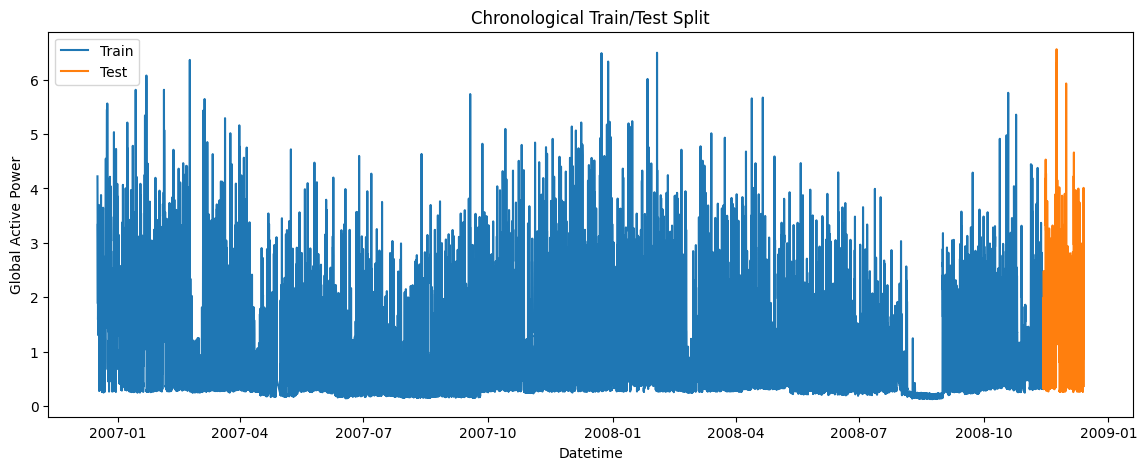

In [35]:
plt.figure(figsize=(14, 5))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.title("Chronological Train/Test Split")
plt.xlabel("Datetime")
plt.ylabel("Global Active Power")
plt.legend()
plt.show()

## Model Identification Summary from EDA

The previous EDA showed that the hourly power consumption series contains clear temporal dependence and repeated seasonal behaviour. The strongest practical seasonal pattern is daily seasonality with a 24-hour cycle. Weekly behaviour with a 168-hour cycle is also relevant, although it is more difficult to model directly using a standard SARIMAX implementation.

Therefore, this notebook uses:
- daily seasonality through the SARIMA seasonal component with `s = 24`;
- weekly seasonality through deterministic Fourier regressors in the SARIMAX candidate model;
- candidate models selected from ACF/PACF diagnostics rather than arbitrary brute-force search.

## Train-only Seasonality Check

The EDA already identified daily and weekly seasonality. Here, the periodogram is recomputed only on the training set to support SARIMA model identification without using information from the test period.

In [36]:
train_clean = train.dropna()

freqs, power = periodogram(train_clean, fs=1)

periods = 1 / freqs[1:]
power_nozero = power[1:]

periodogram_df = pd.DataFrame({
    "period_hours": periods,
    "power": power_nozero
})

top_periods = (
    periodogram_df[
        (periodogram_df["period_hours"] >= 2) &
        (periodogram_df["period_hours"] <= 250)
    ]
    .sort_values("power", ascending=False)
    .head(10)
)

top_periods

,period_hours,power
1395,12.003582,1197.855666
697,24.007163,732.332110
1396,11.994989,498.779923
2792,5.999642,229.664919
698,23.972818,207.617449
1393,12.020803,111.462728
695,24.076149,104.557107
199,83.785000,83.952324
497,33.648594,83.042530
99,167.570000,78.625504


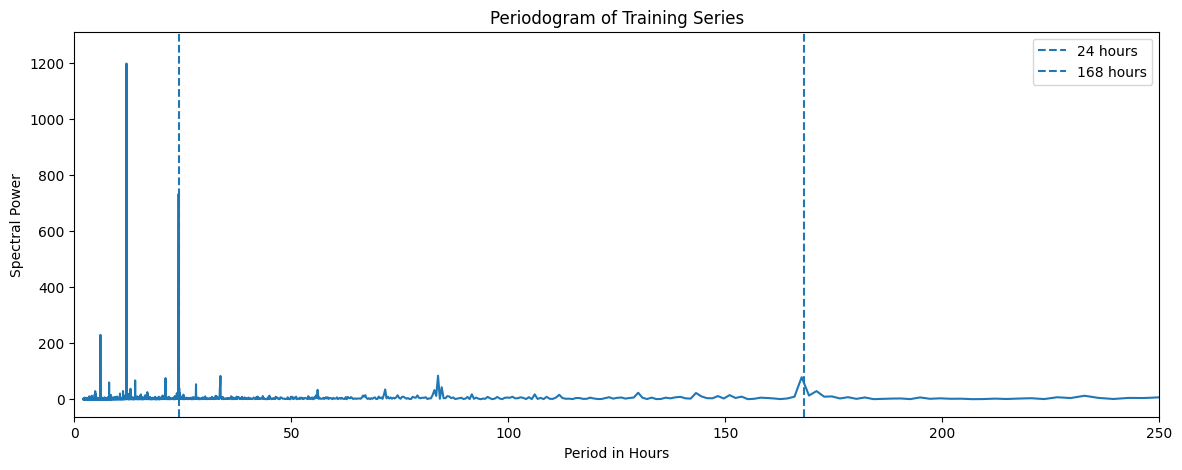

In [37]:
plt.figure(figsize=(14, 5))
plt.plot(periods, power_nozero)
plt.xlim(0, 250)

plt.axvline(24, linestyle="--", label="24 hours")
plt.axvline(168, linestyle="--", label="168 hours")

plt.title("Periodogram of Training Series")
plt.xlabel("Period in Hours")
plt.ylabel("Spectral Power")
plt.legend()
plt.show()

The periodogram is used only to confirm the seasonal periods needed for model specification. The SARIMA component will focus on the 24-hour daily cycle, while the weekly cycle will be handled through Fourier terms in the SARIMAX specification.

In [38]:
def adf_test(series, name):
    series = series.dropna()
    result = adfuller(series, autolag="AIC")
    return {
        "series": name,
        "ADF_statistic": result[0],
        "ADF_p_value": result[1],
        "stationary_by_ADF": result[1] < 0.05
    }

def kpss_test(series, name):
    series = series.dropna()
    result = kpss(series, regression="c", nlags="auto")
    return {
        "series": name,
        "KPSS_statistic": result[0],
        "KPSS_p_value": result[1],
        "stationary_by_KPSS": result[1] > 0.05
    }

In [39]:
series_versions = {
    "original": train,
    "diff_1": train.diff(1),
    "diff_24": train.diff(24),
    "diff_1_24": train.diff(1).diff(24)
}

adf_results = pd.DataFrame([
    adf_test(series, name)
    for name, series in series_versions.items()
])

kpss_results = pd.DataFrame([
    kpss_test(series, name)
    for name, series in series_versions.items()
])

display(adf_results)
display(kpss_results)

,series,ADF_statistic,ADF_p_value,stationary_by_ADF
0,original,-11.134157,3.226497e-20,True
1,diff_1,-32.569435,0.000000e+00,True
2,diff_24,-26.733334,0.000000e+00,True
3,diff_1_24,-29.004616,0.000000e+00,True


,series,KPSS_statistic,KPSS_p_value,stationary_by_KPSS
0,original,2.754135,0.01,False
1,diff_1,0.035616,0.10,True
2,diff_24,0.008419,0.10,True
3,diff_1_24,0.116357,0.10,True


ADF and KPSS are interpreted jointly because they have different null hypotheses. The final differencing choice is not based only on one p-value, but also on the known seasonal structure of hourly electricity consumption. Since the series contains strong daily seasonality, candidate SARIMA models use first differencing and daily seasonal differencing: `d = 1`, `D = 1`, `s = 24`.

## ACF/PACF-Based Model Identification

Following the Box-Jenkins logic used in the reference paper, ACF and PACF are inspected after differencing. The goal is not to search over many arbitrary models, but to define a small set of theoretically justified SARIMA/SARIMAX candidates.

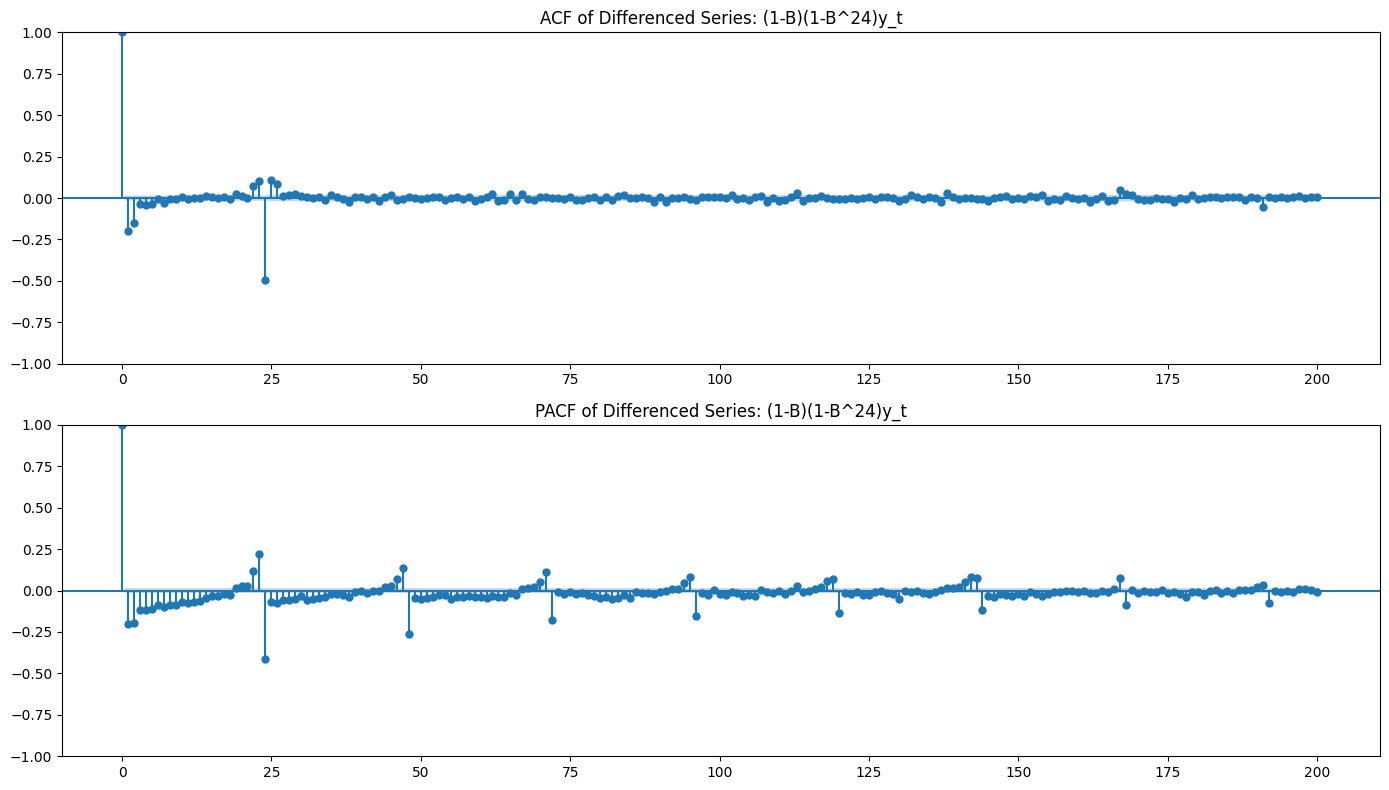

In [40]:
y_diff = train.diff(1).diff(24).dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(y_diff, lags=200, ax=axes[0])
axes[0].set_title("ACF of Differenced Series: (1-B)(1-B^24)y_t")

plot_pacf(y_diff, lags=200, ax=axes[1], method="ywm")
axes[1].set_title("PACF of Differenced Series: (1-B)(1-B^24)y_t")

plt.tight_layout()
plt.show()

Model identification logic:

- ACF spike at lag 1 supports a non-seasonal MA term: `q = 1`.
- PACF spike at lag 1 supports testing an AR term: `p = 1`.
- ACF spike near lag 24 supports a seasonal MA term: `Q = 1`.
- Daily seasonal differencing is represented by `D = 1`, `s = 24`.
- Weekly seasonality is not directly modelled with `s = 168` due to computational cost in standard SARIMAX; it is included through Fourier regressors in one candidate model.

## Evaluation Metrics

Models are evaluated using MAE, RMSE, sMAPE, and MASE. MASE is computed against a 168-hour seasonal naive benchmark because weekly repetition is important in hourly electricity consumption.

In [74]:
def smape(y_true, y_pred):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float) if not isinstance(y_pred, pd.Series) else y_pred.astype(float)

    aligned = pd.concat(
        [y_true.rename("actual"), y_pred.rename("pred")],
        axis=1
    ).dropna()

    denom = (np.abs(aligned["actual"]) + np.abs(aligned["pred"])) / 2
    return np.mean(
        np.where(
            denom == 0,
            0,
            np.abs(aligned["actual"] - aligned["pred"]) / denom
        )
    ) * 100


def wape(y_true, y_pred):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float) if not isinstance(y_pred, pd.Series) else y_pred.astype(float)

    aligned = pd.concat(
        [y_true.rename("actual"), y_pred.rename("pred")],
        axis=1
    ).dropna()

    return (
        np.abs(aligned["actual"] - aligned["pred"]).sum()
        / np.abs(aligned["actual"]).sum()
    ) * 100


def mase(y_true, y_pred, train_series, seasonality=168):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float) if not isinstance(y_pred, pd.Series) else y_pred.astype(float)

    aligned = pd.concat(
        [y_true.rename("actual"), y_pred.rename("pred")],
        axis=1
    ).dropna()

    naive_errors = np.abs(
        train_series.iloc[seasonality:] -
        train_series.shift(seasonality).iloc[seasonality:]
    )

    scale = naive_errors.mean()

    if scale == 0:
        return np.nan

    return mean_absolute_error(aligned["actual"], aligned["pred"]) / scale


def evaluate_forecast(y_true, y_pred, train_series):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float) if not isinstance(y_pred, pd.Series) else y_pred.astype(float)

    aligned = pd.concat(
        [y_true.rename("actual"), y_pred.rename("pred")],
        axis=1
    ).dropna()

    return {
        "MAE": mean_absolute_error(aligned["actual"], aligned["pred"]),
        "RMSE": np.sqrt(mean_squared_error(aligned["actual"], aligned["pred"])),
        "sMAPE": smape(aligned["actual"], aligned["pred"]),
        "WAPE": wape(aligned["actual"], aligned["pred"]),
        "MASE_168": mase(aligned["actual"], aligned["pred"], train_series, seasonality=168)
    }

## Baseline Forecasting Models

Simple baselines are included before SARIMA/SARIMAX fitting. A statistical model is only useful if it improves upon simple naive seasonal forecasts.

In [75]:
def recursive_seasonal_naive(train_series, steps, seasonality, index):
    """
    Multi-step seasonal naive forecast without using test-set actual values.
    Forecasts are generated only from the training history and previous forecasts.
    """
    if len(train_series) < seasonality:
        raise ValueError("Training series is shorter than the seasonal period.")

    last_season = train_series.iloc[-seasonality:].to_numpy()
    preds = []

    for h in range(steps):
        if h < seasonality:
            pred = last_season[h]
        else:
            pred = preds[h - seasonality]
        preds.append(pred)

    return pd.Series(preds, index=index)


baseline_predictions = {
    "Naive_last_value": pd.Series(train.iloc[-1], index=test.index),
    "Seasonal_naive_24h": recursive_seasonal_naive(
        train_series=train,
        steps=len(test),
        seasonality=24,
        index=test.index
    ),
    "Seasonal_naive_168h": recursive_seasonal_naive(
        train_series=train,
        steps=len(test),
        seasonality=168,
        index=test.index
    )
}

baseline_results = []

for name, pred in baseline_predictions.items():
    metrics = evaluate_forecast(test, pred, train)
    metrics["Model"] = name
    metrics["AIC"] = np.nan
    metrics["BIC"] = np.nan
    baseline_results.append(metrics)

baseline_results = pd.DataFrame(baseline_results)
baseline_results = baseline_results[
    ["Model", "MAE", "RMSE", "sMAPE", "WAPE", "MASE_168", "AIC", "BIC"]
]

baseline_results

,Model,MAE,RMSE,sMAPE,WAPE,MASE_168,AIC,BIC
0,Naive_last_value,0.813807,1.021918,60.443381,56.358821,1.208078,NaN,NaN
1,Seasonal_naive_24h,0.760892,1.105255,62.534410,52.694221,1.129526,NaN,NaN
2,Seasonal_naive_168h,0.707084,0.967815,51.686279,48.967863,1.049650,NaN,NaN


## Weekly Fourier Regressors

The reference paper discusses multiple seasonality in ARIMA-type models. Since standard SARIMAX directly handles one seasonal period efficiently, the 24-hour cycle is modelled through the SARIMA seasonal component and the 168-hour weekly cycle is represented using Fourier terms.

In [76]:
fourier_origin = y.index[0]

def make_fourier_terms(index, period, K, prefix, origin=fourier_origin):
    """
    Fourier terms with a fixed time origin.
    This avoids phase inconsistency between train and test.
    """
    t = ((index - origin) / pd.Timedelta(hours=1)).to_numpy()

    data = {}

    for k in range(1, K + 1):
        data[f"{prefix}_sin_{k}"] = np.sin(2 * np.pi * k * t / period)
        data[f"{prefix}_cos_{k}"] = np.cos(2 * np.pi * k * t / period)

    return pd.DataFrame(data, index=index)


weekly_fourier = {}

for K in [1, 2, 3, 5]:
    weekly_fourier[f"F168_K{K}"] = {
        "train": make_fourier_terms(train.index, period=168, K=K, prefix=f"weekly_K{K}"),
        "test": make_fourier_terms(test.index, period=168, K=K, prefix=f"weekly_K{K}")
    }

weekly_fourier["F168_K3"]["train"].head()

,weekly_K3_sin_1,weekly_K3_cos_1,weekly_K3_sin_2,weekly_K3_cos_2,weekly_K3_sin_3,weekly_K3_cos_3
Datetime,,,,,,
2006-12-16 17:00:00,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
2006-12-16 18:00:00,0.037391,0.999301,0.074730,0.997204,0.111964,0.993712
2006-12-16 19:00:00,0.074730,0.997204,0.149042,0.988831,0.222521,0.974928
2006-12-16 20:00:00,0.111964,0.993712,0.222521,0.974928,0.330279,0.943883
2006-12-16 21:00:00,0.149042,0.988831,0.294755,0.955573,0.433884,0.900969


In [77]:
weekly_fourier_all = make_fourier_terms(
    index=y.index,
    period=168,
    K=3,
    prefix="weekly"
)

exog_train = weekly_fourier_all.loc[train.index]
exog_test = weekly_fourier_all.loc[test.index]

exog_train.head()

,weekly_sin_1,weekly_cos_1,weekly_sin_2,weekly_cos_2,weekly_sin_3,weekly_cos_3
Datetime,,,,,,
2006-12-16 17:00:00,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
2006-12-16 18:00:00,0.037391,0.999301,0.074730,0.997204,0.111964,0.993712
2006-12-16 19:00:00,0.074730,0.997204,0.149042,0.988831,0.222521,0.974928
2006-12-16 20:00:00,0.111964,0.993712,0.222521,0.974928,0.330279,0.943883
2006-12-16 21:00:00,0.149042,0.988831,0.294755,0.955573,0.433884,0.900969


## Candidate SARIMA/SARIMAX Models

Three candidate models are fitted:

1. `SARIMA(0,1,1)(0,1,1,24)`  
   Baseline SARIMA structure aligned with the MA and seasonal MA pattern commonly found in load forecasting.

2. `SARIMA(1,1,1)(0,1,1,24)`  
   Adds a non-seasonal AR term to capture short-term dependence suggested by PACF.

3. `SARIMAX(0,1,1)(0,1,1,24) + Fourier(168)`  
   Uses daily SARIMA seasonality and weekly Fourier regressors to capture multiple seasonality.

In [78]:
candidate_models = {}

def add_candidate(name, order, seasonal_order, exog_key=None):
    candidate_models[name] = {
        "order": order,
        "seasonal_order": seasonal_order,
        "exog_train": None if exog_key is None else weekly_fourier[exog_key]["train"],
        "exog_test": None if exog_key is None else weekly_fourier[exog_key]["test"],
        "exog_key": exog_key
    }


# Original daily SARIMA structures
add_candidate(
    "SARIMA_A_(0,1,1)(0,1,1,24)",
    order=(0, 1, 1),
    seasonal_order=(0, 1, 1, 24)
)

add_candidate(
    "SARIMA_B_(1,1,1)(0,1,1,24)",
    order=(1, 1, 1),
    seasonal_order=(0, 1, 1, 24)
)

# Over-differencing checks
add_candidate(
    "SARIMA_C_(1,0,1)(0,1,1,24)",
    order=(1, 0, 1),
    seasonal_order=(0, 1, 1, 24)
)

add_candidate(
    "SARIMA_D_(1,1,1)(0,0,1,24)",
    order=(1, 1, 1),
    seasonal_order=(0, 0, 1, 24)
)

# Slightly richer short-memory candidates
add_candidate(
    "SARIMA_E_(2,1,1)(0,1,1,24)",
    order=(2, 1, 1),
    seasonal_order=(0, 1, 1, 24)
)

add_candidate(
    "SARIMA_F_(1,1,2)(0,1,1,24)",
    order=(1, 1, 2),
    seasonal_order=(0, 1, 1, 24)
)

# Weekly Fourier candidates
add_candidate(
    "SARIMAX_G_(1,1,1)(0,1,1,24)+F168K3",
    order=(1, 1, 1),
    seasonal_order=(0, 1, 1, 24),
    exog_key="F168_K3"
)

add_candidate(
    "SARIMAX_H_(1,0,1)(0,1,1,24)+F168K3",
    order=(1, 0, 1),
    seasonal_order=(0, 1, 1, 24),
    exog_key="F168_K3"
)

add_candidate(
    "SARIMAX_I_(1,1,1)(0,0,1,24)+F168K3",
    order=(1, 1, 1),
    seasonal_order=(0, 0, 1, 24),
    exog_key="F168_K3"
)

add_candidate(
    "SARIMAX_J_(1,1,1)(1,1,1,24)+F168K3",
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 24),
    exog_key="F168_K3"
)

add_candidate(
    "SARIMAX_K_(1,1,1)(0,1,1,24)+F168K5",
    order=(1, 1, 1),
    seasonal_order=(0, 1, 1, 24),
    exog_key="F168_K5"
)

list(candidate_models.keys())

['SARIMA_A_(0,1,1)(0,1,1,24)',
 'SARIMA_B_(1,1,1)(0,1,1,24)',
 'SARIMA_C_(1,0,1)(0,1,1,24)',
 'SARIMA_D_(1,1,1)(0,0,1,24)',
 'SARIMA_E_(2,1,1)(0,1,1,24)',
 'SARIMA_F_(1,1,2)(0,1,1,24)',
 'SARIMAX_G_(1,1,1)(0,1,1,24)+F168K3',
 'SARIMAX_H_(1,0,1)(0,1,1,24)+F168K3',
 'SARIMAX_I_(1,1,1)(0,0,1,24)+F168K3',
 'SARIMAX_J_(1,1,1)(1,1,1,24)+F168K3',
 'SARIMAX_K_(1,1,1)(0,1,1,24)+F168K5']

In [ ]:
def get_max_abs_ar_ma_param(result):
    params = result.params.copy()
    ar_ma_params = params[
        params.index.str.contains("ar", case=False)
        | params.index.str.contains("ma", case=False)
    ]

    if len(ar_ma_params) == 0:
        return np.nan

    return ar_ma_params.abs().max()

def residual_diagnostics_summary(result):
    resid = result.resid.dropna()

    lb = acorr_ljungbox(
        resid,
        lags=[1, 24, 48, 168],
        return_df=True
    )

    arch = het_arch(resid)

    return {
        "LB_p_1": lb.loc[1, "lb_pvalue"],
        "LB_p_24": lb.loc[24, "lb_pvalue"],
        "LB_p_48": lb.loc[48, "lb_pvalue"],
        "LB_p_168": lb.loc[168, "lb_pvalue"],
        "ARCH_p": arch[1]
    }


model_results = []
fitted_models = {}
forecasts = {}
conf_intervals = {}
failed_models = []

for name, spec in candidate_models.items():
    print(f"Fitting {name}")

    try:
        model = SARIMAX(
            train,
            order=spec["order"],
            seasonal_order=spec["seasonal_order"],
            exog=spec["exog_train"],
            enforce_stationarity=True,
            enforce_invertibility=True
        )

        result = model.fit(disp=False, maxiter=300)

        fitted_models[name] = result

        forecast_obj = result.get_forecast(
            steps=len(test),
            exog=spec["exog_test"]
        )

        pred = forecast_obj.predicted_mean
        ci = forecast_obj.conf_int(alpha=0.05)

        forecasts[name] = pred
        conf_intervals[name] = ci

        metrics = evaluate_forecast(test, pred, train)
        diagnostics = residual_diagnostics_summary(result)

        metrics["Model"] = name
        metrics["AIC"] = result.aic
        metrics["BIC"] = result.bic
        metrics["Converged"] = result.mle_retvals.get("converged", np.nan)
        metrics["Max_abs_AR_MA_param"] = get_max_abs_ar_ma_param(result)
        metrics["Boundary_OK"] = metrics["Max_abs_AR_MA_param"] < 0.98

        metrics.update(diagnostics)

        model_results.append(metrics)

    except Exception as e:
        failed_models.append({
            "Model": name,
            "Error": str(e)
        })

model_results = pd.DataFrame(model_results)

model_results = model_results[
    [
        "Model",
        "MAE",
        "RMSE",
        "sMAPE",
        "WAPE",
        "MASE_168",
        "AIC",
        "BIC",
        "Converged",
        "Max_abs_AR_MA_param",
        "Boundary_OK",
        "LB_p_1",
        "LB_p_24",
        "LB_p_48",
        "LB_p_168",
        "ARCH_p"
    ]
].sort_values("RMSE").reset_index(drop=True)

failed_models = pd.DataFrame(failed_models)

display(model_results)
display(failed_models)

Fitting SARIMA_A_(0,1,1)(0,1,1,24)
Fitting SARIMA_B_(1,1,1)(0,1,1,24)
Fitting SARIMA_C_(1,0,1)(0,1,1,24)
Fitting SARIMA_D_(1,1,1)(0,0,1,24)
Fitting SARIMA_E_(2,1,1)(0,1,1,24)
Fitting SARIMA_F_(1,1,2)(0,1,1,24)
Fitting SARIMAX_G_(1,1,1)(0,1,1,24)+F168K3
Fitting SARIMAX_H_(1,0,1)(0,1,1,24)+F168K3
Fitting SARIMAX_I_(1,1,1)(0,0,1,24)+F168K3
Fitting SARIMAX_J_(1,1,1)(1,1,1,24)+F168K3
Fitting SARIMAX_K_(1,1,1)(0,1,1,24)+F168K5


,Model,MAE,RMSE,sMAPE,WAPE,MASE_168,AIC,BIC,Converged,Max_abs_AR_MA_param,Boundary_OK,LB_p_1,LB_p_24,LB_p_48,LB_p_168,ARCH_p
0,"SARIMA_B_(1,1,1)(0,1,1,24)",0.614563,0.825741,48.809566,42.560504,0.912305,30385.474431,30416.374744,True,0.989781,False,3.602854e-02,5.997843e-24,4.929270e-31,3.482644e-62,1.658254e-120
1,"SARIMA_E_(2,1,1)(0,1,1,24)",0.614901,0.826092,48.850700,42.583914,0.912807,30374.213563,30412.838955,True,0.988503,False,9.740438e-01,2.669263e-20,2.820256e-27,1.351061e-58,1.518726e-122
2,"SARIMA_C_(1,0,1)(0,1,1,24)",0.594805,0.863630,45.375340,41.192210,0.882975,30470.748685,30501.649237,True,0.944476,True,3.266921e-03,2.230276e-64,5.005979e-69,2.986282e-112,9.140115e-173
3,"SARIMAX_I_(1,1,1)(0,0,1,24)+F168K3",0.790399,1.021614,60.672251,54.737728,1.173329,32674.489253,32751.754370,True,0.995375,False,1.360819e-14,1.632737e-202,0.000000e+00,0.000000e+00,3.472999e-100
4,"SARIMA_D_(1,1,1)(0,0,1,24)",0.794751,1.038019,60.929577,55.039102,1.179789,32715.266866,32746.172913,True,0.995487,False,7.200858e-14,6.245074e-196,0.000000e+00,0.000000e+00,2.540790e-101
5,"SARIMA_A_(0,1,1)(0,1,1,24)",1.130869,1.391378,129.582151,78.316349,1.678748,32912.653437,32935.828672,True,0.950537,True,8.231704e-14,2.128461e-248,1.341857e-254,3.897197e-271,1.415653e-151


,Model,Error
0,"SARIMA_F_(1,1,2)(0,1,1,24)",Unable to allocate 346. MiB for an array with ...
1,"SARIMAX_G_(1,1,1)(0,1,1,24)+F168K3",Unable to allocate 333. MiB for an array with ...
2,"SARIMAX_H_(1,0,1)(0,1,1,24)+F168K3",Unable to allocate 320. MiB for an array with ...
3,"SARIMAX_J_(1,1,1)(1,1,1,24)+F168K3",Unable to allocate 333. MiB for an array with ...
4,"SARIMAX_K_(1,1,1)(0,1,1,24)+F168K5",Unable to allocate 333. MiB for an array with ...


## Model Comparison

The final model is selected using both test-set forecasting accuracy and residual adequacy. AIC and BIC are reported, but the final choice is not based only on in-sample information criteria.

In [82]:
all_results = pd.concat(
    [baseline_results, model_results],
    ignore_index=True
).sort_values("RMSE").reset_index(drop=True)

display(all_results)


valid_sarima = model_results[
    (model_results["Converged"] == True)
    & (model_results["Boundary_OK"] == True)
].copy()

diagnostic_ok = valid_sarima[
    (valid_sarima["LB_p_24"] > 0.05)
    & (valid_sarima["LB_p_168"] > 0.05)
    & (valid_sarima["ARCH_p"] > 0.05)
].copy()

if len(diagnostic_ok) > 0:
    selection_pool = diagnostic_ok
    selection_reason = "forecast accuracy and residual diagnostics are acceptable"
else:
    selection_pool = valid_sarima
    selection_reason = "forecast accuracy is best among valid candidates, but residual diagnostics are not fully adequate"

best_sarima_name = selection_pool.sort_values(
    ["RMSE", "MASE_168", "AIC"]
).iloc[0]["Model"]

best_sarima_result = fitted_models[best_sarima_name]

print("Selected model:", best_sarima_name)
print("Selection reason:", selection_reason)

display(
    model_results[
        model_results["Model"].eq(best_sarima_name)
    ]
)

,Model,MAE,RMSE,sMAPE,WAPE,MASE_168,AIC,BIC,Converged,Max_abs_AR_MA_param,Boundary_OK,LB_p_1,LB_p_24,LB_p_48,LB_p_168,ARCH_p
0,"SARIMA_B_(1,1,1)(0,1,1,24)",0.614563,0.825741,48.809566,42.560504,0.912305,30385.474431,30416.374744,True,0.989781,False,3.602854e-02,5.997843e-24,4.929270e-31,3.482644e-62,1.658254e-120
1,"SARIMA_E_(2,1,1)(0,1,1,24)",0.614901,0.826092,48.850700,42.583914,0.912807,30374.213563,30412.838955,True,0.988503,False,9.740438e-01,2.669263e-20,2.820256e-27,1.351061e-58,1.518726e-122
2,"SARIMA_C_(1,0,1)(0,1,1,24)",0.594805,0.863630,45.375340,41.192210,0.882975,30470.748685,30501.649237,True,0.944476,True,3.266921e-03,2.230276e-64,5.005979e-69,2.986282e-112,9.140115e-173
3,Seasonal_naive_168h,0.707084,0.967815,51.686279,48.967863,1.049650,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"SARIMAX_I_(1,1,1)(0,0,1,24)+F168K3",0.790399,1.021614,60.672251,54.737728,1.173329,32674.489253,32751.754370,True,0.995375,False,1.360819e-14,1.632737e-202,0.000000e+00,0.000000e+00,3.472999e-100
5,Naive_last_value,0.813807,1.021918,60.443381,56.358821,1.208078,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,"SARIMA_D_(1,1,1)(0,0,1,24)",0.794751,1.038019,60.929577,55.039102,1.179789,32715.266866,32746.172913,True,0.995487,False,7.200858e-14,6.245074e-196,0.000000e+00,0.000000e+00,2.540790e-101
7,Seasonal_naive_24h,0.760892,1.105255,62.534410,52.694221,1.129526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,"SARIMA_A_(0,1,1)(0,1,1,24)",1.130869,1.391378,129.582151,78.316349,1.678748,32912.653437,32935.828672,True,0.950537,True,8.231704e-14,2.128461e-248,1.341857e-254,3.897197e-271,1.415653e-151


Selected model: SARIMA_C_(1,0,1)(0,1,1,24)
Selection reason: forecast accuracy is best among valid candidates, but residual diagnostics are not fully adequate


,Model,MAE,RMSE,sMAPE,WAPE,MASE_168,AIC,BIC,Converged,Max_abs_AR_MA_param,Boundary_OK,LB_p_1,LB_p_24,LB_p_48,LB_p_168,ARCH_p
2,"SARIMA_C_(1,0,1)(0,1,1,24)",0.594805,0.86363,45.37534,41.19221,0.882975,30470.748685,30501.649237,True,0.944476,True,0.003267,2.230276e-64,5.005979e-69,2.986282e-112,9.140115e-173


The best SARIMA/SARIMAX candidate is selected for residual diagnostics. If a naive baseline outperforms all SARIMA candidates, this must be reported directly rather than hidden.

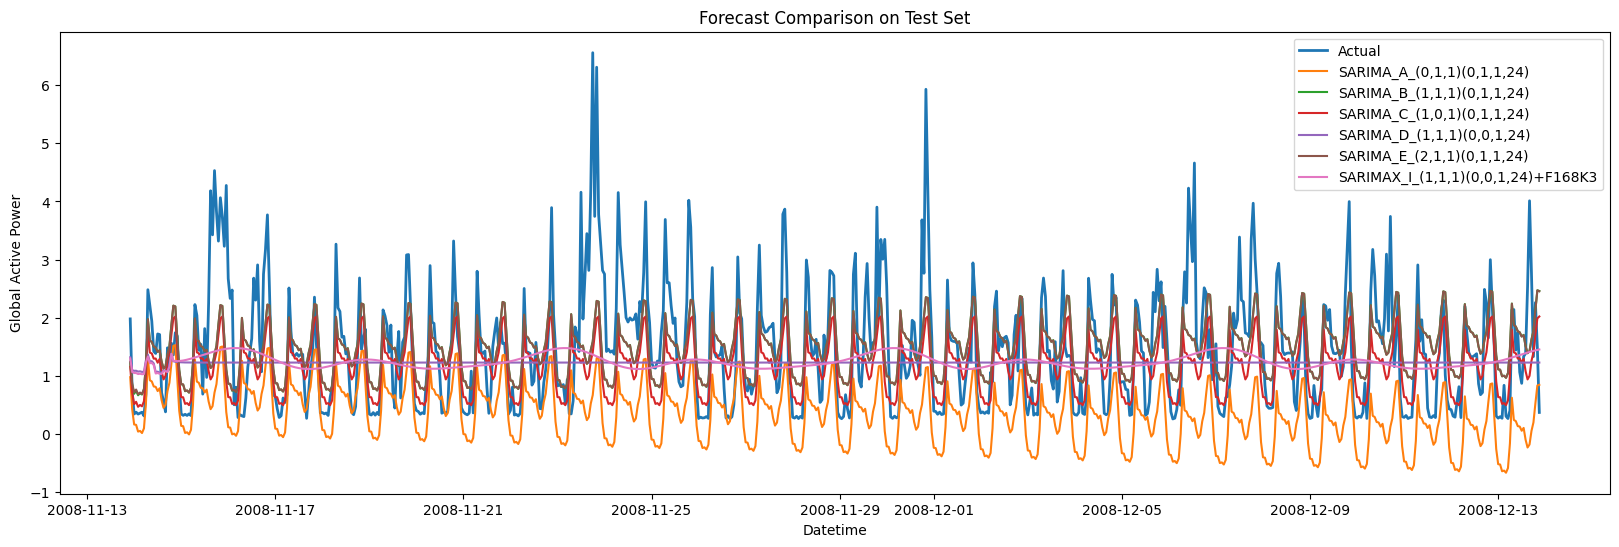

In [84]:
plt.figure(figsize=(20, 6))

plt.plot(test.index, test, label="Actual", linewidth=2)

for name, pred in forecasts.items():
    plt.plot(pred.index, pred, label=name)

plt.title("Forecast Comparison on Test Set")
plt.xlabel("Datetime")
plt.ylabel("Global Active Power")
plt.legend()
plt.show()

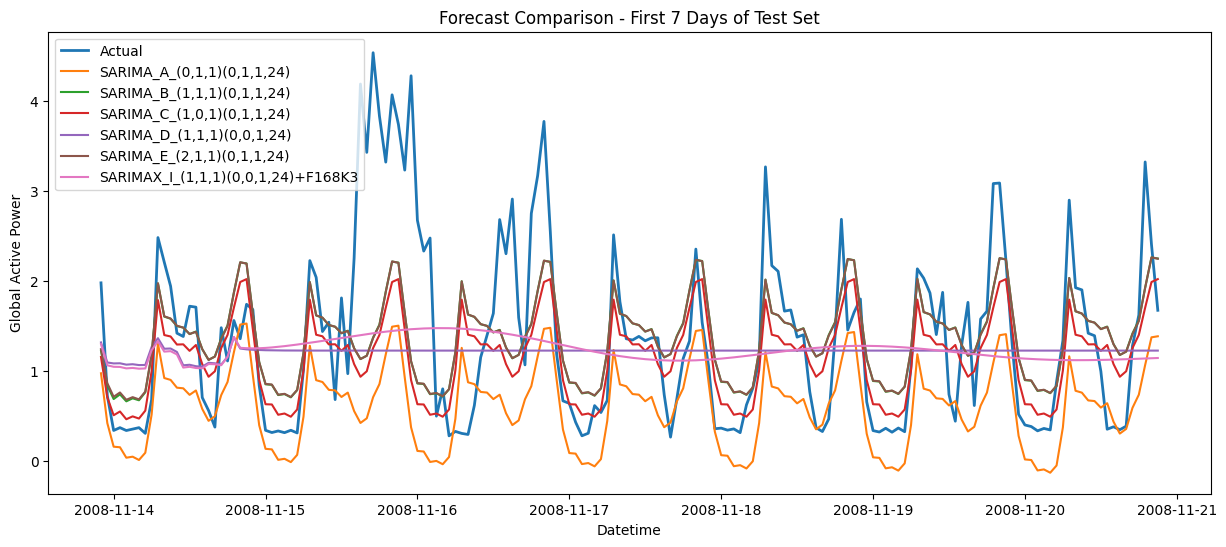

In [85]:
plt.figure(figsize=(15, 6))

plt.plot(test.iloc[:168].index, test.iloc[:168], label="Actual", linewidth=2)

for name, pred in forecasts.items():
    plt.plot(pred.iloc[:168].index, pred.iloc[:168], label=name)

plt.title("Forecast Comparison - First 7 Days of Test Set")
plt.xlabel("Datetime")
plt.ylabel("Global Active Power")
plt.legend()
plt.show()

In [88]:
train_log = np.log1p(train)
test_log = np.log1p(test)

log_model_results = []
log_fitted_models = {}
log_forecasts = {}
log_conf_intervals = {}

log_candidate_names = [
    "SARIMA_B_(1,1,1)(0,1,1,24)",
    "SARIMA_C_(1,0,1)(0,1,1,24)",
    "SARIMAX_G_(1,1,1)(0,1,1,24)+F168K3",
    "SARIMAX_H_(1,0,1)(0,1,1,24)+F168K3",
    "SARIMAX_K_(1,1,1)(0,1,1,24)+F168K5"
]

for base_name in log_candidate_names:
    spec = candidate_models[base_name]
    name = "LOG_" + base_name

    print(f"Fitting {name}")

    try:
        model = SARIMAX(
            train_log,
            order=spec["order"],
            seasonal_order=spec["seasonal_order"],
            exog=spec["exog_train"],
            enforce_stationarity=True,
            enforce_invertibility=True
        )

        result = model.fit(disp=False, maxiter=300)

        forecast_obj = result.get_forecast(
            steps=len(test),
            exog=spec["exog_test"]
        )

        pred_log = forecast_obj.predicted_mean
        ci_log = forecast_obj.conf_int(alpha=0.05)

        pred = np.expm1(pred_log)
        ci = np.expm1(ci_log)

        log_fitted_models[name] = result
        log_forecasts[name] = pred
        log_conf_intervals[name] = ci

        metrics = evaluate_forecast(test, pred, train)
        diagnostics = residual_diagnostics_summary(result)

        metrics["Model"] = name
        metrics["AIC"] = result.aic
        metrics["BIC"] = result.bic
        metrics["Converged"] = result.mle_retvals.get("converged", np.nan)
        metrics["Max_abs_AR_MA_param"] = get_max_abs_ar_ma_param(result)
        metrics["Boundary_OK"] = metrics["Max_abs_AR_MA_param"] < 0.98

        metrics.update(diagnostics)

        log_model_results.append(metrics)

    except Exception as e:
        print("Failed:", name, e)

log_model_results = pd.DataFrame(log_model_results)

log_model_results = log_model_results[
    [
        "Model",
        "MAE",
        "RMSE",
        "sMAPE",
        "WAPE",
        "MASE_168",
        "AIC",
        "BIC",
        "Converged",
        "Max_abs_AR_MA_param",
        "Boundary_OK",
        "LB_p_1",
        "LB_p_24",
        "LB_p_48",
        "LB_p_168",
        "ARCH_p"
    ]
].sort_values("RMSE").reset_index(drop=True)

display(log_model_results)

Fitting LOG_SARIMA_B_(1,1,1)(0,1,1,24)
Fitting LOG_SARIMA_C_(1,0,1)(0,1,1,24)
Failed: LOG_SARIMA_C_(1,0,1)(0,1,1,24) Unable to allocate 320. MiB for an array with shape (50, 50, 16757) and data type float64
Fitting LOG_SARIMAX_G_(1,1,1)(0,1,1,24)+F168K3
Failed: LOG_SARIMAX_G_(1,1,1)(0,1,1,24)+F168K3 Unable to allocate 333. MiB for an array with shape (51, 51, 16757) and data type float64
Fitting LOG_SARIMAX_H_(1,0,1)(0,1,1,24)+F168K3
Failed: LOG_SARIMAX_H_(1,0,1)(0,1,1,24)+F168K3 Unable to allocate 320. MiB for an array with shape (50, 50, 16758) and data type float64
Fitting LOG_SARIMAX_K_(1,1,1)(0,1,1,24)+F168K5
Failed: LOG_SARIMAX_K_(1,1,1)(0,1,1,24)+F168K5 Unable to allocate 333. MiB for an array with shape (51, 51, 16758) and data type float64


,Model,MAE,RMSE,sMAPE,WAPE,MASE_168,AIC,BIC,Converged,Max_abs_AR_MA_param,Boundary_OK,LB_p_1,LB_p_24,LB_p_48,LB_p_168,ARCH_p
0,"LOG_SARIMA_B_(1,1,1)(0,1,1,24)",0.596034,0.829269,47.065451,41.277304,0.884799,-106.067303,-75.16699,True,0.988369,False,0.000012,2.276293e-47,6.546324e-58,1.193052e-89,4.706581e-33


In [89]:
combined_model_results = pd.concat(
    [model_results, log_model_results],
    ignore_index=True
).sort_values("RMSE").reset_index(drop=True)

display(combined_model_results)

valid_combined = combined_model_results[
    (combined_model_results["Converged"] == True)
    & (combined_model_results["Boundary_OK"] == True)
].copy()

diagnostic_ok_combined = valid_combined[
    (valid_combined["LB_p_24"] > 0.05)
    & (valid_combined["LB_p_168"] > 0.05)
    & (valid_combined["ARCH_p"] > 0.05)
].copy()

if len(diagnostic_ok_combined) > 0:
    final_pool = diagnostic_ok_combined
    final_selection_reason = "forecast accuracy and residual diagnostics are acceptable"
else:
    final_pool = valid_combined
    final_selection_reason = "forecast accuracy is best among valid models, but residual diagnostics are not fully adequate"

final_model_name = final_pool.sort_values(
    ["RMSE", "MASE_168", "AIC"]
).iloc[0]["Model"]

print("Final selected candidate:", final_model_name)
print("Reason:", final_selection_reason)

display(
    combined_model_results[
        combined_model_results["Model"].eq(final_model_name)
    ]
)

,Model,MAE,RMSE,sMAPE,WAPE,MASE_168,AIC,BIC,Converged,Max_abs_AR_MA_param,Boundary_OK,LB_p_1,LB_p_24,LB_p_48,LB_p_168,ARCH_p
0,"SARIMA_B_(1,1,1)(0,1,1,24)",0.614563,0.825741,48.809566,42.560504,0.912305,30385.474431,30416.374744,True,0.989781,False,3.602854e-02,5.997843e-24,4.929270e-31,3.482644e-62,1.658254e-120
1,"SARIMA_E_(2,1,1)(0,1,1,24)",0.614901,0.826092,48.850700,42.583914,0.912807,30374.213563,30412.838955,True,0.988503,False,9.740438e-01,2.669263e-20,2.820256e-27,1.351061e-58,1.518726e-122
2,"LOG_SARIMA_B_(1,1,1)(0,1,1,24)",0.596034,0.829269,47.065451,41.277304,0.884799,-106.067303,-75.166990,True,0.988369,False,1.214781e-05,2.276293e-47,6.546324e-58,1.193052e-89,4.706581e-33
3,"SARIMA_C_(1,0,1)(0,1,1,24)",0.594805,0.863630,45.375340,41.192210,0.882975,30470.748685,30501.649237,True,0.944476,True,3.266921e-03,2.230276e-64,5.005979e-69,2.986282e-112,9.140115e-173
4,"SARIMAX_I_(1,1,1)(0,0,1,24)+F168K3",0.790399,1.021614,60.672251,54.737728,1.173329,32674.489253,32751.754370,True,0.995375,False,1.360819e-14,1.632737e-202,0.000000e+00,0.000000e+00,3.472999e-100
5,"SARIMA_D_(1,1,1)(0,0,1,24)",0.794751,1.038019,60.929577,55.039102,1.179789,32715.266866,32746.172913,True,0.995487,False,7.200858e-14,6.245074e-196,0.000000e+00,0.000000e+00,2.540790e-101
6,"SARIMA_A_(0,1,1)(0,1,1,24)",1.130869,1.391378,129.582151,78.316349,1.678748,32912.653437,32935.828672,True,0.950537,True,8.231704e-14,2.128461e-248,1.341857e-254,3.897197e-271,1.415653e-151


Final selected candidate: SARIMA_C_(1,0,1)(0,1,1,24)
Reason: forecast accuracy is best among valid models, but residual diagnostics are not fully adequate


,Model,MAE,RMSE,sMAPE,WAPE,MASE_168,AIC,BIC,Converged,Max_abs_AR_MA_param,Boundary_OK,LB_p_1,LB_p_24,LB_p_48,LB_p_168,ARCH_p
3,"SARIMA_C_(1,0,1)(0,1,1,24)",0.594805,0.86363,45.37534,41.19221,0.882975,30470.748685,30501.649237,True,0.944476,True,0.003267,2.230276e-64,5.005979e-69,2.986282e-112,9.140115e-173


## Final Model Selection

Based on the updated model comparison, the selected final forecasting model is:

`SARIMA_C_(1,0,1)(0,1,1,24)`

This corresponds to the following SARIMAX specification:

`SARIMAX(1,0,1)(0,1,1,24)`

SARIMA_C_(1,0,1)(0,1,1,24) is selected as the final forecasting benchmark because it provides the best valid out-of-sample performance among models that converge and do not show boundary problems. The model improves over the weekly seasonal naive benchmark, as indicated by MASE_168 below 1. However, residual diagnostics show remaining autocorrelation and heteroskedasticity, so the model should be interpreted as an acceptable forecasting benchmark rather than a fully adequate statistical representation of the data-generating process. 

### Forecasting performance

The selected model achieved the following test-set performance:

| Metric | Value |
|---|---:|
| MAE | 0.5948 |
| RMSE | 0.8636 |
| sMAPE | 45.38% |
| WAPE | 41.19% |
| MASE_168 | 0.8830 |
| AIC | 30470.75 |
| BIC | 30501.65 |

The MASE value is below 1, which means the selected SARIMA model outperforms the weekly seasonal naive benchmark. This supports the use of a SARIMA-type model for the hourly electricity consumption forecasting task.

### Parameter interpretation

The estimated model parameters are:

| Parameter | Coefficient | p-value | Interpretation |
|---|---:|---:|---|
| AR(1) | 0.6386 | < 0.001 | Significant short-term autoregressive dependence |
| MA(1) | 0.0169 | 0.085 | Weak and not significant at the 5% level |
| Seasonal MA(24) | -0.9445 | < 0.001 | Strong daily seasonal moving-average effect |
| sigma² | 0.3604 | < 0.001 | Residual variance estimate |

The AR(1) term is statistically significant, showing that current electricity consumption is strongly related to recent past values. The seasonal MA(24) term is also highly significant, confirming the importance of the daily seasonal pattern in hourly electricity consumption. The MA(1) term is not significant at the 5% level, but it is retained because the full model provides the best valid forecasting performance among the tested candidates.

### Diagnostic assessment

The model passes the basic convergence and boundary checks. The Ljung-Box result at lag 1 is acceptable, with a p-value of `0.95`, suggesting no serious first-order residual autocorrelation.

However, the residual diagnostics are not fully adequate. The model summary shows that residuals are not normally distributed, as indicated by the Jarque-Bera test with p-value `0.00`. The heteroskedasticity test also gives p-value `0.00`, indicating non-constant residual variance. Therefore, the model should not be interpreted as a complete statistical representation of the data-generating process.

The selected model should instead be interpreted as the best SARIMA forecasting benchmark among the valid candidates tested in this notebook.

### Final conclusion

`SARIMA_C_(1,0,1)(0,1,1,24)` is selected as the final forecasting model because it achieves the best valid out-of-sample forecasting performance, converges successfully, avoids boundary problems, and captures the main daily seasonal structure of the hourly electricity consumption series.

At the same time, residual diagnostics show remaining limitations, especially non-normality and heteroskedasticity. Therefore, the model is acceptable for forecasting comparison and robustness analysis, but it should not be claimed to be a fully adequate statistical model.

## Residual Diagnostics

Residual diagnostics are used to evaluate whether the selected SARIMA/SARIMAX model has adequately captured temporal dependence. The diagnostics include residual plots, residual ACF/PACF, Ljung-Box tests, and ARCH tests.

                                     SARIMAX Results                                      
Dep. Variable:                Global_active_power   No. Observations:                16757
Model:             SARIMAX(1, 0, 1)x(0, 1, 1, 24)   Log Likelihood              -15231.374
Date:                            Sun, 24 May 2026   AIC                          30470.749
Time:                                    01:57:18   BIC                          30501.649
Sample:                                12-16-2006   HQIC                         30480.946
                                     - 11-13-2008                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6386      0.008     83.912      0.000       0.624       0.654
ma.L1          0.0169      0.010   

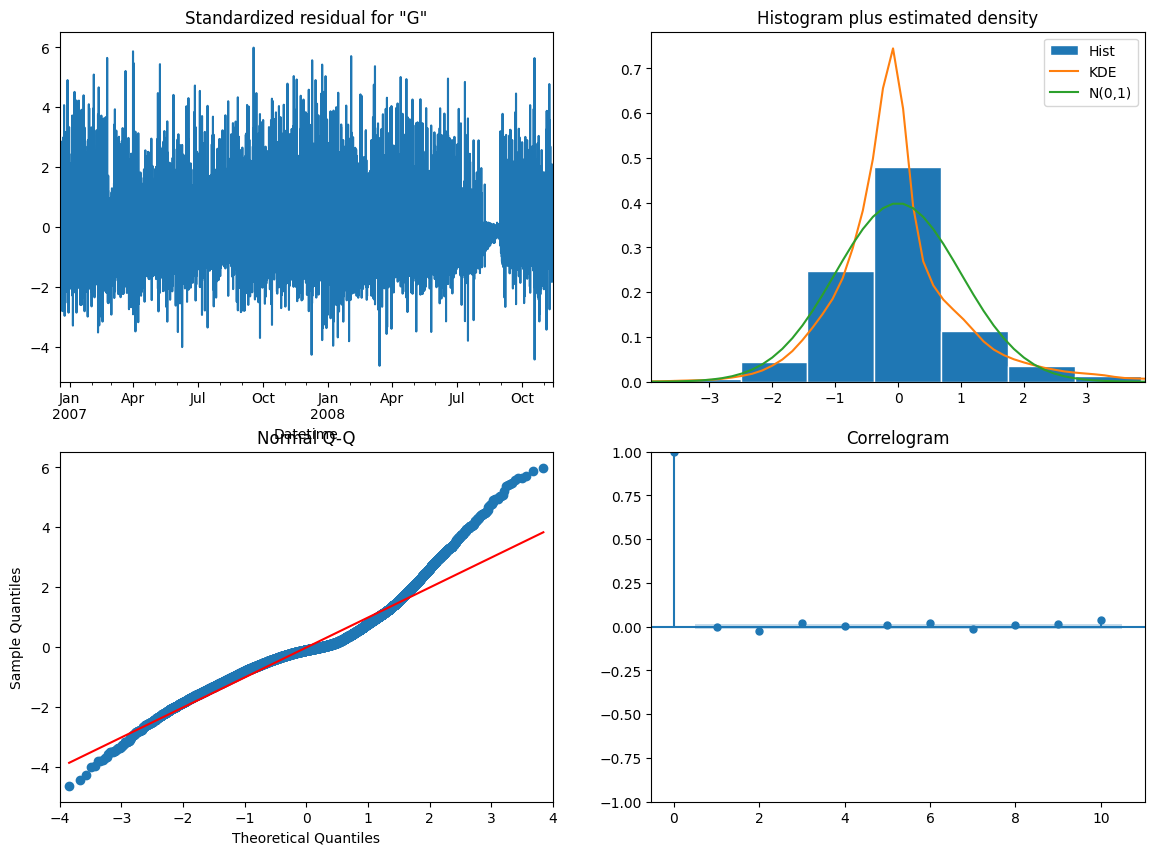

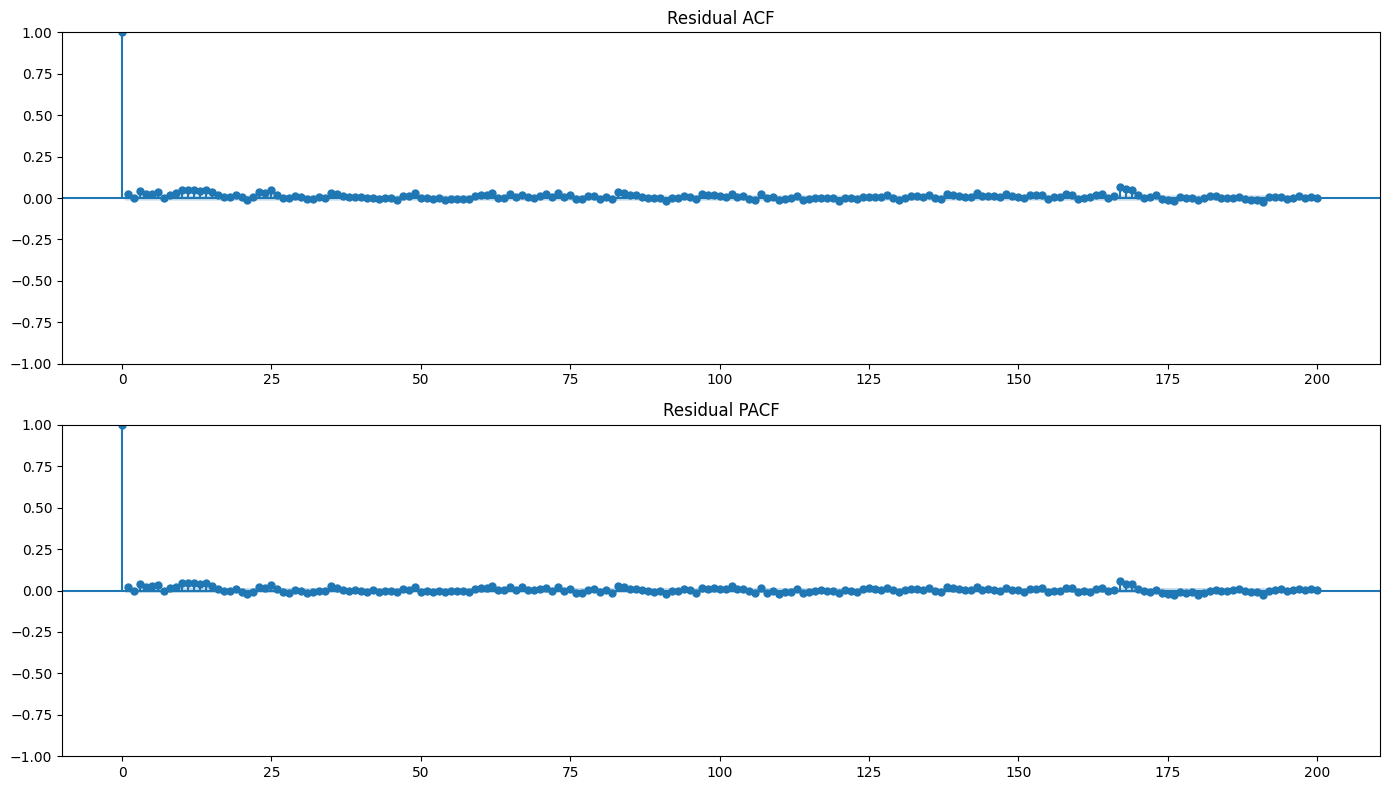

,lb_stat,lb_pvalue
1,8.652058,3.266921e-03
24,373.285107,2.230276e-64
48,461.869072,5.005979e-69
168,966.076725,2.986282e-112


,Test,Value
0,ARCH LM statistic,8.341988e+02
1,ARCH LM p-value,9.140115e-173
2,ARCH F statistic,8.773535e+01
3,ARCH F p-value,2.599944e-177


In [106]:
if final_model_name.startswith("LOG_"):
    final_result = log_fitted_models[final_model_name]
    final_pred = log_forecasts[final_model_name]
    final_ci = log_conf_intervals[final_model_name]
else:
    final_result = fitted_models[final_model_name]
    final_pred = forecasts[final_model_name]
    final_ci = conf_intervals[final_model_name]

print(final_result.summary())

final_result.plot_diagnostics(figsize=(14, 10))
plt.show()

final_resid = final_result.resid.dropna()
resid = final_resid.copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(final_resid, lags=200, ax=axes[0])
axes[0].set_title("Residual ACF")

plot_pacf(final_resid, lags=200, ax=axes[1], method="ywm")
axes[1].set_title("Residual PACF")

plt.tight_layout()
plt.show()

final_ljung_results = acorr_ljungbox(
    final_resid,
    lags=[1, 24, 48, 168],
    return_df=True
)

final_arch_test = het_arch(final_resid)

final_arch_results = pd.DataFrame({
    "Test": ["ARCH LM statistic", "ARCH LM p-value", "ARCH F statistic", "ARCH F p-value"],
    "Value": final_arch_test
})

display(final_ljung_results)
display(final_arch_results)

In [107]:
lb_pass = (final_ljung_results["lb_pvalue"] > 0.05).all()
arch_pass = final_arch_test[1] > 0.05

print("Ljung-Box passed all tested lags:", lb_pass)
print("ARCH test passed:", arch_pass)

if lb_pass and arch_pass:
    print("Residual diagnostics are acceptable.")
else:
    print("Residual diagnostics are not fully adequate. The model should be reported as a forecasting benchmark, not as a complete statistical explanation of the series.")

Ljung-Box passed all tested lags: False
ARCH test passed: False
Residual diagnostics are not fully adequate. The model should be reported as a forecasting benchmark, not as a complete statistical explanation of the series.


In [108]:
ljung_results = acorr_ljungbox(
    resid,
    lags=[24, 48, 168],
    return_df=True
)

ljung_results

,lb_stat,lb_pvalue
24,373.285107,2.230276e-64
48,461.869072,5.005979e-69
168,966.076725,2.986282e-112


In [109]:
arch_test = het_arch(resid)

arch_results = pd.DataFrame({
    "Metric": ["LM statistic", "LM p-value", "F statistic", "F p-value"],
    "Value": [arch_test[0], arch_test[1], arch_test[2], arch_test[3]]
})

arch_results

,Metric,Value
0,LM statistic,8.341988e+02
1,LM p-value,9.140115e-173
2,F statistic,8.773535e+01
3,F p-value,2.599944e-177


Residual interpretation:

- Ljung-Box p-value > 0.05 suggests no statistically significant residual autocorrelation at the tested lag.
- Ljung-Box p-value < 0.05 means the model still leaves temporal structure unexplained.
- Significant ARCH results indicate changing residual variance, which is common in household electricity data.

## Forecast Interval Analysis

Prediction intervals are inspected because they represent forecast uncertainty. This is consistent with the reference paper, where higher noise levels increased the forecast confidence interval width.

Mean 95% prediction interval width: 3.157598593632719


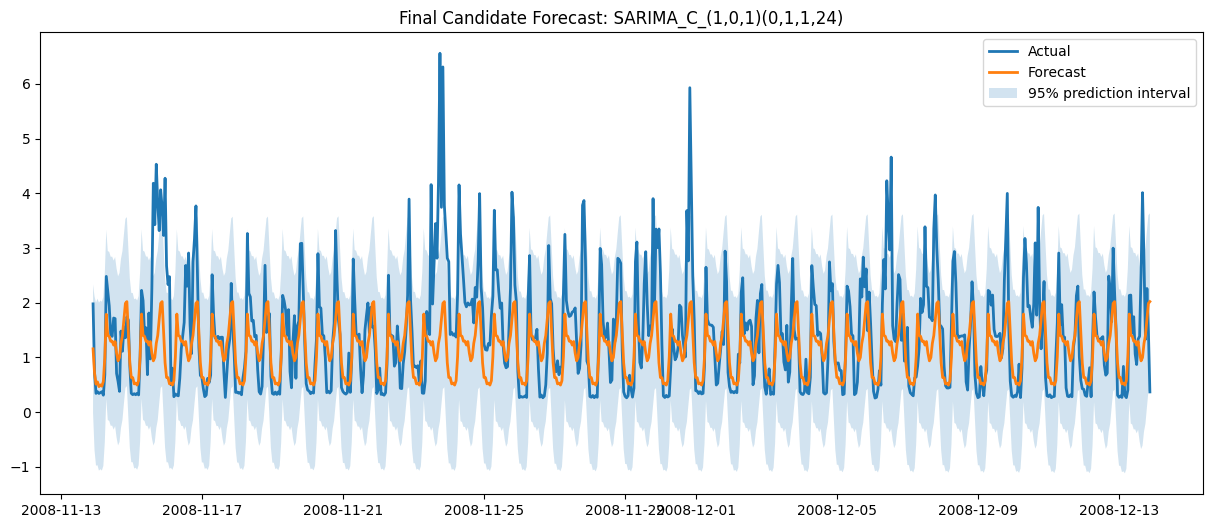

In [110]:
mean_ci_width = (final_ci.iloc[:, 1] - final_ci.iloc[:, 0]).mean()

print("Mean 95% prediction interval width:", mean_ci_width)

plt.figure(figsize=(15, 6))
plt.plot(test.index, test, label="Actual", linewidth=2)
plt.plot(test.index, final_pred, label="Forecast", linewidth=2)
plt.fill_between(
    test.index,
    final_ci.iloc[:, 0],
    final_ci.iloc[:, 1],
    alpha=0.2,
    label="95% prediction interval"
)
plt.title(f"Final Candidate Forecast: {final_model_name}")
plt.legend()
plt.show()

In [111]:
mean_ci_width = (final_ci.iloc[:, 1] - final_ci.iloc[:, 0]).mean()

print("Mean 95% prediction interval width:", mean_ci_width)

Mean 95% prediction interval width: 3.157598593632719


## Noise Robustness Experiment

Following the robustness logic of the reference paper, Gaussian white noise is added to the training series at different noise-to-signal ratios. The selected SARIMA/SARIMAX structure is re-estimated under each noise level, and the resulting forecasts are compared using error metrics and prediction interval width.

The noise standard deviation is defined as:

\[
\sigma_{noise} = NSR \times \sigma_{signal}
\]

where \(\sigma_{signal}\) is calculated from the differenced training series.

In [112]:
# Use raw training series for noise injection, following the paper logic.
signal_for_noise = train.diff(1).diff(24).dropna()
sigma_signal = signal_for_noise.std()

noise_levels = [0.10, 1.00, 2.00]
seeds = range(1)

print("Sigma signal:", sigma_signal)

Sigma signal: 0.9025528369659799


In [119]:
def get_final_spec_from_name(model_name):
    if model_name.startswith("LOG_"):
        base_name = model_name.replace("LOG_", "")
        transform = "log1p"
    else:
        base_name = model_name
        transform = "raw"

    return candidate_models[base_name], transform


final_spec, final_transform = get_final_spec_from_name(final_model_name)

noise_rows = []

for nsr in noise_levels:
    sigma_noise = nsr * sigma_signal

    for seed in seeds:
        rng = np.random.default_rng(seed)

        noise = rng.normal(
            loc=0,
            scale=sigma_noise,
            size=len(train)
        )

        train_noisy_raw = pd.Series(
            train.values + noise,
            index=train.index
        )

        # Prevent invalid log1p values if noise makes values <= -1
        if final_transform == "log1p":
            train_noisy_model = np.log1p(train_noisy_raw.clip(lower=0))
        else:
            train_noisy_model = train_noisy_raw

        try:
            model_noisy = SARIMAX(
                train_noisy_model,
                order=final_spec["order"],
                seasonal_order=final_spec["seasonal_order"],
                exog=final_spec["exog_train"],
                enforce_stationarity=True,
                enforce_invertibility=True
            )

            result_noisy = model_noisy.fit(disp=False,maxiter=100)

            forecast_obj_noisy = result_noisy.get_forecast(
                steps=len(test),
                exog=final_spec["exog_test"]
            )

            pred_noisy = forecast_obj_noisy.predicted_mean
            ci_noisy = forecast_obj_noisy.conf_int(alpha=0.05)

            if final_transform == "log1p":
                pred_noisy_eval = np.expm1(pred_noisy)
                ci_noisy_eval = np.expm1(ci_noisy)
            else:
                pred_noisy_eval = pred_noisy
                ci_noisy_eval = ci_noisy

            metrics = evaluate_forecast(test, pred_noisy_eval, train)

            metrics["NSR"] = nsr
            metrics["Seed"] = seed
            metrics["sigma_noise"] = sigma_noise
            metrics["AIC"] = result_noisy.aic
            metrics["BIC"] = result_noisy.bic
            metrics["Mean_CI_Width"] = (
                ci_noisy_eval.iloc[:, 1] - ci_noisy_eval.iloc[:, 0]
            ).mean()
            metrics["Converged"] = result_noisy.mle_retvals.get("converged", np.nan)
            metrics["Max_abs_AR_MA_param"] = get_max_abs_ar_ma_param(result_noisy)

            for param_name, param_value in result_noisy.params.items():
                metrics[f"param_{param_name}"] = param_value

            noise_rows.append(metrics)

        except Exception as e:
            noise_rows.append({
                "NSR": nsr,
                "Seed": seed,
                "sigma_noise": sigma_noise,
                "Error": str(e)
            })

noise_results = pd.DataFrame(noise_rows)

display(noise_results.head())

,MAE,RMSE,sMAPE,WAPE,MASE_168,NSR,Seed,sigma_noise,AIC,BIC,Mean_CI_Width,Converged,Max_abs_AR_MA_param,param_ar.L1,param_ma.L1,param_ma.S.L24,param_sigma2,Error
0,0.597184,0.863166,45.584012,41.356915,0.886505,0.1,0,0.090255,30922.389183,30953.289735,3.17649,True,0.945318,0.641535,0.001221,-0.945318,0.370233,NaN
1,NaN,NaN,NaN,NaN,NaN,1.0,0,0.902553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unable to allocate 320. MiB for an array with ...
2,NaN,NaN,NaN,NaN,NaN,2.0,0,1.805106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unable to allocate 320. MiB for an array with ...


In [120]:
noise_summary = noise_results.groupby("NSR").agg(
    MAE_mean=("MAE", "mean"),
    MAE_std=("MAE", "std"),
    RMSE_mean=("RMSE", "mean"),
    RMSE_std=("RMSE", "std"),
    sMAPE_mean=("sMAPE", "mean"),
    WAPE_mean=("WAPE", "mean"),
    MASE_168_mean=("MASE_168", "mean"),
    AIC_mean=("AIC", "mean"),
    BIC_mean=("BIC", "mean"),
    Mean_CI_Width_mean=("Mean_CI_Width", "mean"),
    Mean_CI_Width_std=("Mean_CI_Width", "std"),
    Max_abs_AR_MA_param_mean=("Max_abs_AR_MA_param", "mean")
).reset_index()

display(noise_summary)

,NSR,MAE_mean,MAE_std,RMSE_mean,RMSE_std,sMAPE_mean,WAPE_mean,MASE_168_mean,AIC_mean,BIC_mean,Mean_CI_Width_mean,Mean_CI_Width_std,Max_abs_AR_MA_param_mean
0,0.1,0.597184,NaN,0.863166,NaN,45.584012,41.356915,0.886505,30922.389183,30953.289735,3.17649,NaN,0.945318
1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [121]:
base_metrics = evaluate_forecast(test, final_pred, train)

base_metrics["NSR"] = 0.00
base_metrics["sigma_noise"] = 0.00
base_metrics["AIC"] = final_result.aic
base_metrics["BIC"] = final_result.bic

final_ci_width = (final_ci.iloc[:, 1] - final_ci.iloc[:, 0]).mean()
base_metrics["Mean_CI_Width"] = final_ci_width

noise_comparison = pd.concat(
    [pd.DataFrame([base_metrics]), noise_results],
    ignore_index=True
)

noise_comparison = noise_comparison[
    ["NSR", "sigma_noise", "MAE", "RMSE", "sMAPE", "MASE_168", "AIC", "BIC", "Mean_CI_Width"]
]

noise_comparison

,NSR,sigma_noise,MAE,RMSE,sMAPE,MASE_168,AIC,BIC,Mean_CI_Width
0,0.0,0.000000,0.594805,0.863630,45.375340,0.882975,30470.748685,30501.649237,3.157599
1,0.1,0.090255,0.597184,0.863166,45.584012,0.886505,30922.389183,30953.289735,3.176490
2,1.0,0.902553,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.0,1.805106,NaN,NaN,NaN,NaN,NaN,NaN,NaN


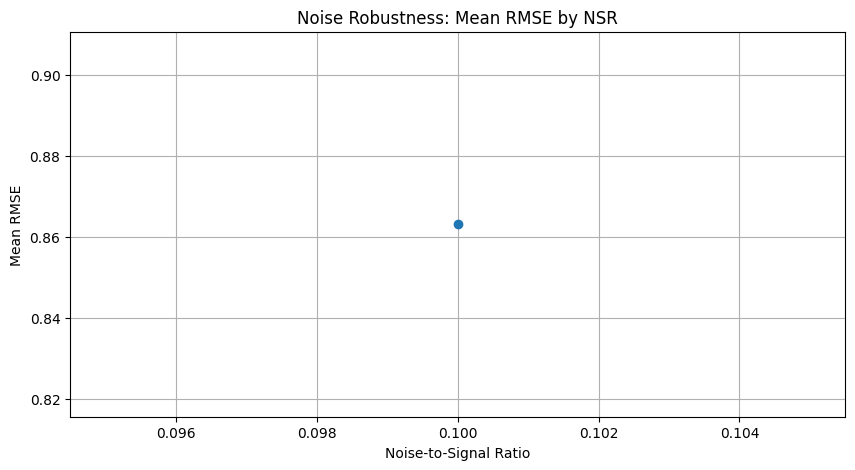

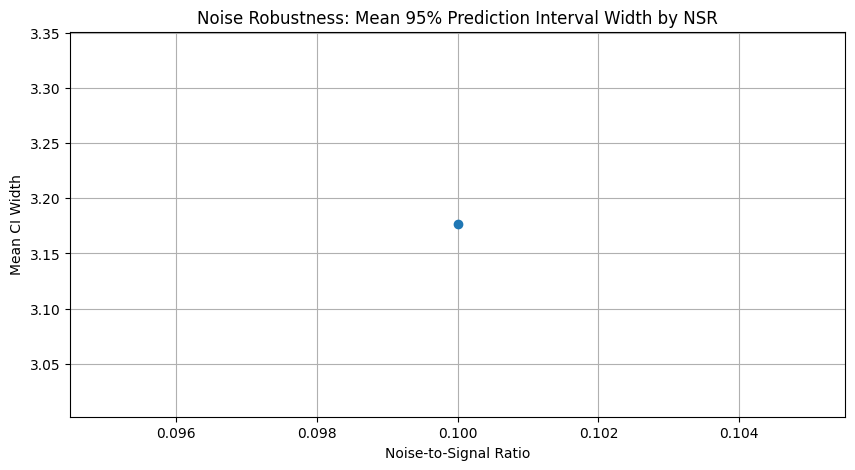

In [122]:
plt.figure(figsize=(10, 5))
plt.plot(noise_summary["NSR"], noise_summary["RMSE_mean"], marker="o")
plt.title("Noise Robustness: Mean RMSE by NSR")
plt.xlabel("Noise-to-Signal Ratio")
plt.ylabel("Mean RMSE")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(noise_summary["NSR"], noise_summary["Mean_CI_Width_mean"], marker="o")
plt.title("Noise Robustness: Mean 95% Prediction Interval Width by NSR")
plt.xlabel("Noise-to-Signal Ratio")
plt.ylabel("Mean CI Width")
plt.grid(True)
plt.show()

The noise robustness experiment evaluates whether the selected SARIMA/SARIMAX structure remains stable under increasing random disturbance. The main expected pattern is that higher NSR values increase forecast error and widen the prediction interval.